# 03 — Feature Extraction

Convert every 5-second WAV segment into a pre-computed spectrogram saved as a `.npy` file.

Pre-computing features is mandatory on CPU. Computing spectrograms on-the-fly during training would be 10 to 20 times slower.

### Feature types

| Feature | Description | Strength |
|---|---|---|
| Log-mel | Log-compressed mel spectrogram | Fast, well understood, good baseline |
| PCEN | Per-Channel Energy Normalization | Adaptive gain, robust to level differences, suppresses stationary noise |

Both are saved. The training notebook switches between them with a single config flag.

### Output structure

```
data/features/
    logmel/
        BG/
            IDMT_..._0000.npy    # shape: (64, 216)
        Car/
        ...
    pcen/
        BG/
        ...
```

Each `.npy` file is a 2D float32 array of shape `(n_mels, time_frames)`, treated as a grayscale image by the CNN.

### Spectrogram parameters

```
sr         = 22050 Hz
duration   = 5.0 s
n_fft      = 1024      # ~46 ms window
hop_length = 512       # ~23 ms hop, 50% overlap
n_mels     = 64
fmin       = 50 Hz
fmax       = 8000 Hz
output     = (64, 216) # 64 mel bins x 216 time frames
```


## 0. Imports & configuration


In [2]:
import time as _time
_NOTEBOOK_START = _time.perf_counter()

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import soundfile as sf
from tqdm.notebook import tqdm

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT         = Path("data")
SEG_DIR      = ROOT / "segments"
FEAT_DIR     = ROOT / "features"
MANIFEST_CSV = ROOT / "segments_manifest.csv"

# ── Audio parameters (must match Notebook 02) ────────────────────────────────
SR       = 22050
DURATION = 5.0

# ── Spectrogram parameters ────────────────────────────────────────────────────
N_FFT      = 1024
HOP_LENGTH = 512
N_MELS     = 64
FMIN       = 50
FMAX       = 8000

# Expected output shape: (N_MELS, T) where T = floor(SR*DURATION / HOP) + 1
T_FRAMES   = int(np.floor(SR * DURATION / HOP_LENGTH)) + 1
print(f"Expected spectrogram shape: ({N_MELS}, {T_FRAMES})")

# ── Classes ───────────────────────────────────────────────────────────────────
CLASS2IDX = {
    'BG': 0, 'MC': 1, 'Car': 2, 'Bus': 3, 'Truck': 4,
    'Tram': 5, 'Horn': 6, 'Dog': 7, 'Construction': 8, 'Siren': 9
}
CLASSES = list(CLASS2IDX.keys())

# ── Create output folders ─────────────────────────────────────────────────────
for feat_type in ['logmel', 'pcen']:
    for cls in CLASSES:
        (FEAT_DIR / feat_type / cls).mkdir(parents=True, exist_ok=True)

print(f"Output: {FEAT_DIR.resolve()}")

Expected spectrogram shape: (64, 216)
Output: C:\Users\anyal\Desktop\S8\Pole_ProjetS8\data\features


---
## 1. Feature extraction functions

### 1a. Log-mel spectrogram

Standard pipeline: STFT -> mel filterbank -> power -> log compression.

$$S_{\text{logmel}} = 10 \cdot \log_{10}(\text{MelSpectrogram}(x) + \epsilon)$$


In [5]:
def compute_logmel(y: np.ndarray, sr: int = SR) -> np.ndarray:
    """
    Compute a log-mel spectrogram.
    Returns float32 array of shape (N_MELS, T_FRAMES).
    """
    S = librosa.feature.melspectrogram(
        y=y, sr=sr,
        n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX,
        power=2.0
    )
    # Convert power to dB, reference = max value
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db.astype(np.float32)

### 1b. PCEN — Per-Channel Energy Normalization

PCEN replaces log compression with an adaptive gain control:

$$\text{PCEN}(t,f) = \left(\frac{E(t,f)}{(\epsilon + M(t,f))^{\alpha}} + \delta\right)^r - \delta^r$$

where $M(t,f)$ is a per-channel IIR smoother that tracks slowly varying background energy. The key effect is suppression of stationary noise and normalisation for recording level, which makes the features more robust to microphone differences.

Parameters (Lostanlen et al. 2018): `gain=0.98`, `bias=2.0`, `power=0.5`, `time_constant=0.400s`.


In [6]:
def compute_pcen(y: np.ndarray, sr: int = SR) -> np.ndarray:
    """
    Compute PCEN spectrogram.
    Returns float32 array of shape (N_MELS, T_FRAMES).
    """
    # Step 1: mel filterbank on raw amplitude spectrogram (power=1 for PCEN)
    S = librosa.feature.melspectrogram(
        y=y, sr=sr,
        n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX,
        power=1.0    # PCEN expects amplitude, not power
    )
    # Step 2: apply PCEN
    # time_constant controls how fast the background estimate adapts
    P = librosa.pcen(
        S * (2**31),   # librosa expects large dynamic range
        sr=sr,
        hop_length=HOP_LENGTH,
        gain=0.98,
        bias=2.0,
        power=0.5,
        time_constant=0.400,
        eps=1e-6
    )
    return P.astype(np.float32)

---
## 2. Visual comparison: log-mel vs PCEN

One example per class, showing waveform, log-mel, and PCEN side by side.


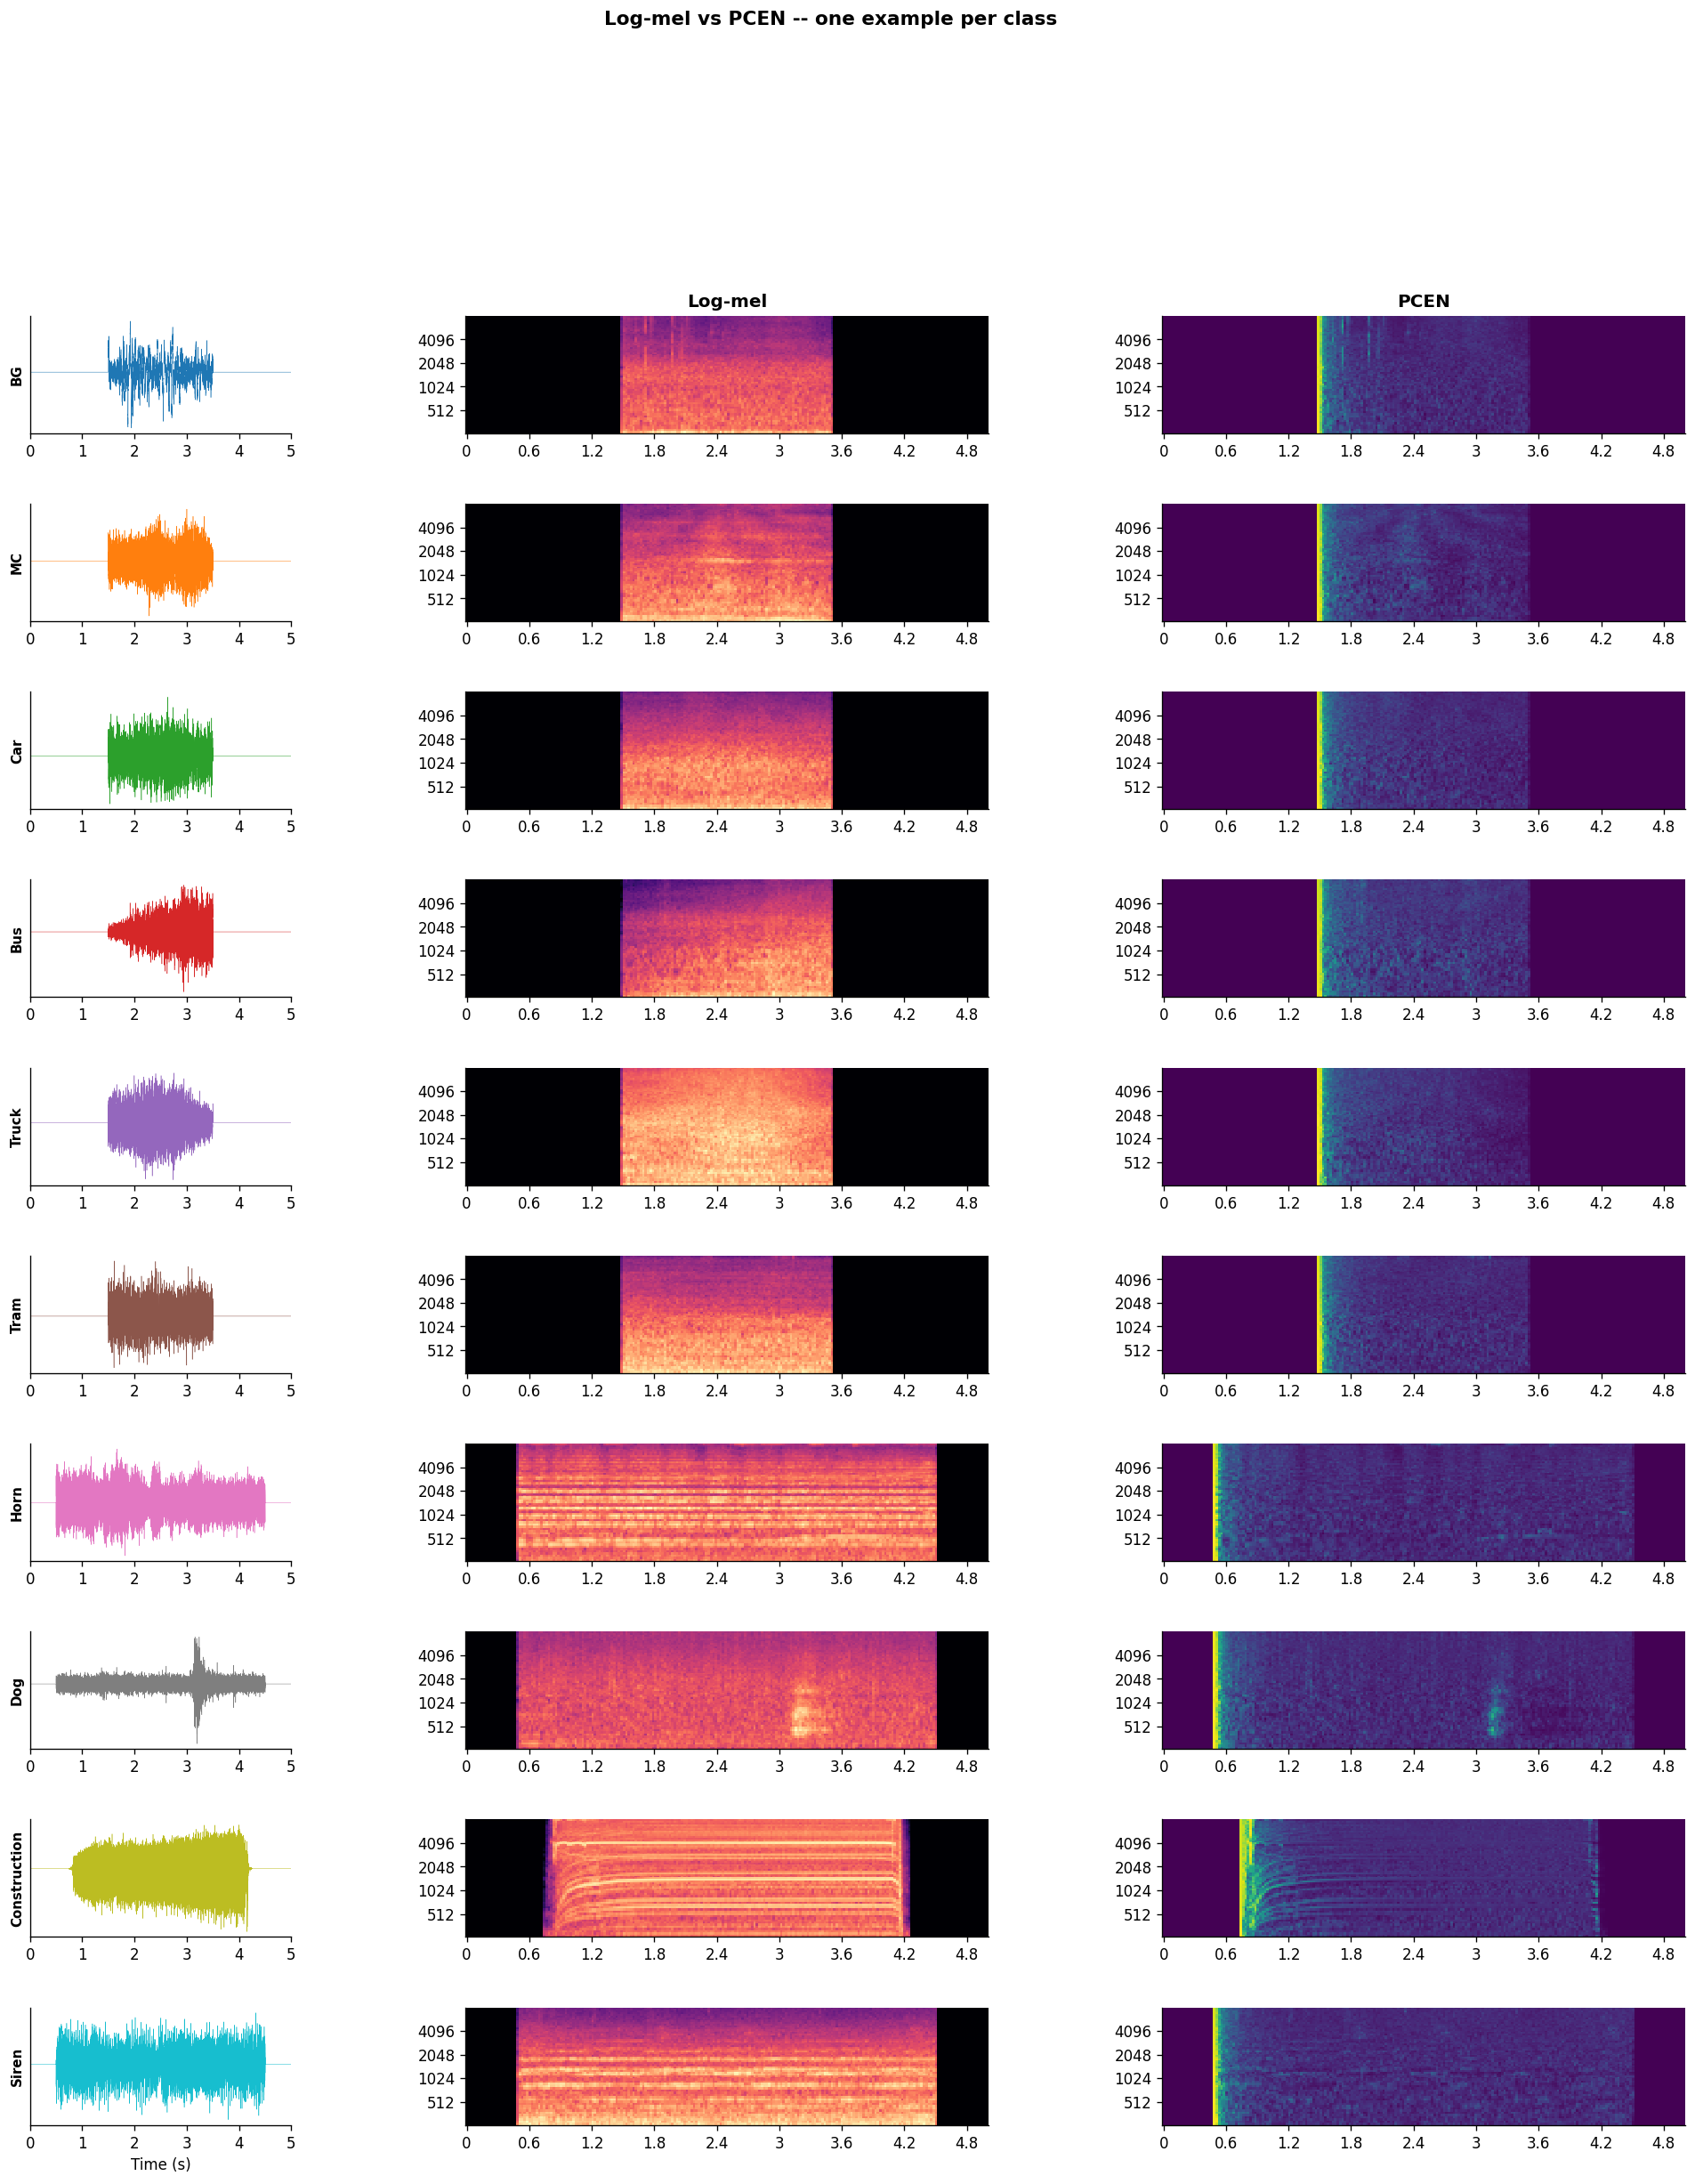

Key difference: PCEN suppresses the stationary background and highlights transient events.
BG class should look 'flatter' in PCEN than in log-mel.


In [7]:
manifest = pd.read_csv(MANIFEST_CSV)

fig = plt.figure(figsize=(20, len(CLASSES) * 2.2))
fig.suptitle('Log-mel vs PCEN -- one example per class', fontweight='bold', fontsize=13, y=1.01)

gs = gridspec.GridSpec(len(CLASSES), 3, figure=fig,
                       width_ratios=[1, 2, 2], wspace=0.4, hspace=0.6)

for i, cls in enumerate(CLASSES):
    subset = manifest[manifest['label'] == cls]
    row    = subset.sample(1, random_state=42).iloc[0]
    y, _   = librosa.load(row['out_path'], sr=SR, mono=True)

    logmel = compute_logmel(y)
    pcen   = compute_pcen(y)

    # Waveform
    ax_w = fig.add_subplot(gs[i, 0])
    times = np.linspace(0, DURATION, len(y))
    ax_w.plot(times, y, linewidth=0.3, color=plt.cm.tab10.colors[CLASS2IDX[cls]])
    ax_w.set_ylabel(cls, fontweight='bold', fontsize=9)
    ax_w.set_xlim(0, DURATION)
    ax_w.set_yticks([])
    if i == len(CLASSES) - 1:
        ax_w.set_xlabel('Time (s)')

    # Log-mel
    ax_l = fig.add_subplot(gs[i, 1])
    librosa.display.specshow(logmel, sr=SR, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel',
                             fmin=FMIN, fmax=FMAX, ax=ax_l, cmap='magma')
    if i == 0:
        ax_l.set_title('Log-mel', fontweight='bold')
    ax_l.set_ylabel('')
    ax_l.set_xlabel('')

    # PCEN
    ax_p = fig.add_subplot(gs[i, 2])
    librosa.display.specshow(pcen, sr=SR, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel',
                             fmin=FMIN, fmax=FMAX, ax=ax_p, cmap='viridis')
    if i == 0:
        ax_p.set_title('PCEN', fontweight='bold')
    ax_p.set_ylabel('')
    ax_p.set_xlabel('')

plt.savefig('03_logmel_vs_pcen.png', bbox_inches='tight')
plt.show()
print("Key difference: PCEN suppresses the stationary background and highlights transient events.")
print("BG class should look 'flatter' in PCEN than in log-mel.")

---
## 3. Compute & save all features

Every segment in the manifest is processed and both `logmel` and `pcen` arrays are saved as `.npy` files. The output filename matches the WAV stem exactly so they stay in sync.

Expected runtime on CPU: 10 to 20 minutes for roughly 7700 clips × 2 features.


In [8]:
errors        = []
shape_mismatch = []
feat_records  = []

for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc='Extracting features'):
    wav_path = Path(row['out_path'])
    label    = row['label']
    stem     = wav_path.stem

    logmel_path = FEAT_DIR / 'logmel' / label / f"{stem}.npy"
    pcen_path   = FEAT_DIR / 'pcen'   / label / f"{stem}.npy"

    try:
        y, _ = librosa.load(wav_path, sr=SR, mono=True)

        logmel = compute_logmel(y)
        pcen   = compute_pcen(y)

        # Guard: check shape is exactly what we expect
        if logmel.shape != (N_MELS, T_FRAMES):
            shape_mismatch.append((str(wav_path), logmel.shape))

        np.save(logmel_path, logmel)
        np.save(pcen_path,   pcen)

        feat_records.append({
            **row.to_dict(),
            'logmel_path': str(logmel_path),
            'pcen_path':   str(pcen_path),
        })

    except Exception as e:
        errors.append({'file': str(wav_path), 'error': str(e)})

print(f"\nOK: Features extracted: {len(feat_records)}")
if shape_mismatch:
    print(f"WARNING:  Shape mismatches: {len(shape_mismatch)}")
    for f, s in shape_mismatch[:5]:
        print(f"  {f}: {s}")
if errors:
    print(f"WARNING:  Errors: {len(errors)}")
    for e in errors[:5]:
        print(f"  {e['file']}: {e['error']}")

Extracting features:   0%|          | 0/8125 [00:00<?, ?it/s]


OK: Features extracted: 8125


---
## 4. Save the feature manifest

The segment manifest is extended with `logmel_path` and `pcen_path` columns and saved as `features_manifest.csv`. This file is the complete index for all subsequent notebooks.


In [9]:
feat_manifest = pd.DataFrame(feat_records)
feat_manifest_path = ROOT / "features_manifest.csv"
feat_manifest.to_csv(feat_manifest_path, index=False)

print(f"Feature manifest saved -> {feat_manifest_path}")
print(f"Total entries : {len(feat_manifest)}")
print(f"Columns       : {list(feat_manifest.columns)}")
feat_manifest.head(3)

Feature manifest saved -> data\features_manifest.csv
Total entries : 8125
Columns       : ['source_path', 'label', 'source_db', 'mic_type', 'file_id', 'out_path', 'label_idx', 'logmel_path', 'pcen_path']


,source_path,label,source_db,mic_type,file_id,out_path,label_idx,logmel_path,pcen_path
0,data\IDMT_Traffic\audio\2019-11-19-15-25_Lange...,Car,IDMT,ME,2019-11-19-15-25_Langewiesener-Strasse_50Kmh_3...,data\segments\Car\IDMT_2019-11-19-15-25_Langew...,2,data\features\logmel\Car\IDMT_2019-11-19-15-25...,data\features\pcen\Car\IDMT_2019-11-19-15-25_L...
1,data\us8k_filtered\train\Horn\72567-1-4-1.wav,Horn,US8K,US8K,72567-1-4-1,data\segments\Horn\US8K_72567-1-4-1_0000.wav,6,data\features\logmel\Horn\US8K_72567-1-4-1_000...,data\features\pcen\Horn\US8K_72567-1-4-1_0000.npy
2,data\MELAUDIS_Vehicles\SW_07\2023-08-04_12-6-3...,MC,MelVeh,MelVeh_SW_07,2023-08-04_12-6-33.0-Swanston7_FF_1V-MC_L1_1La...,data\segments\MC\MelVeh_2023-08-04_12-6-33.0-S...,1,data\features\logmel\MC\MelVeh_2023-08-04_12-6...,data\features\pcen\MC\MelVeh_2023-08-04_12-6-3...


---
## 5. Verification

### 5a. Shape and dtype check

Load 20 randomly sampled `.npy` files and confirm shape `(64, 216)` and dtype `float32`.


In [10]:
sample = feat_manifest.sample(20, random_state=42)
all_ok = True

for _, row in sample.iterrows():
    for feat_type, col in [('logmel', 'logmel_path'), ('pcen', 'pcen_path')]:
        arr = np.load(row[col])
        ok  = (arr.shape == (N_MELS, T_FRAMES) and arr.dtype == np.float32)
        if not ok:
            print(f"FAIL: {row[col]}: shape={arr.shape} dtype={arr.dtype}")
            all_ok = False

if all_ok:
    print(f"OK: All 20 sampled features: shape=({N_MELS}, {T_FRAMES}), dtype=float32")

OK: All 20 sampled features: shape=(64, 216), dtype=float32


### 5b. Value range check

Log-mel values are in dB, typically in the range -80 to 0. PCEN values are positive floats, typically 0 to ~20.


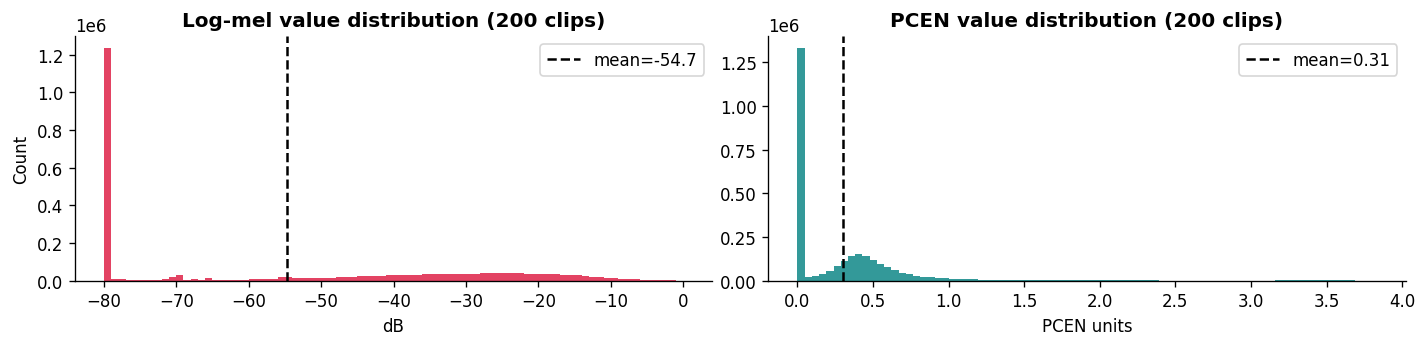

Log-mel  -- min: -80.0  max: 0.0  mean: -54.7
PCEN     -- min: 0.000  max: 3.832  mean: 0.305


In [11]:
logmel_vals, pcen_vals = [], []

for _, row in feat_manifest.sample(200, random_state=42).iterrows():
    logmel_vals.append(np.load(row['logmel_path']).ravel())
    pcen_vals.append(np.load(row['pcen_path']).ravel())

logmel_flat = np.concatenate(logmel_vals)
pcen_flat   = np.concatenate(pcen_vals)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].hist(logmel_flat, bins=80, color='crimson', alpha=0.8, edgecolor='none')
axes[0].set_title('Log-mel value distribution (200 clips)', fontweight='bold')
axes[0].set_xlabel('dB')
axes[0].set_ylabel('Count')
axes[0].axvline(logmel_flat.mean(), color='black', linestyle='--',
                label=f'mean={logmel_flat.mean():.1f}')
axes[0].legend()

axes[1].hist(pcen_flat, bins=80, color='teal', alpha=0.8, edgecolor='none')
axes[1].set_title('PCEN value distribution (200 clips)', fontweight='bold')
axes[1].set_xlabel('PCEN units')
axes[1].axvline(pcen_flat.mean(), color='black', linestyle='--',
                label=f'mean={pcen_flat.mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('03_value_distributions.png', bbox_inches='tight')
plt.show()

print(f"Log-mel  -- min: {logmel_flat.min():.1f}  max: {logmel_flat.max():.1f}  mean: {logmel_flat.mean():.1f}")
print(f"PCEN     -- min: {pcen_flat.min():.3f}  max: {pcen_flat.max():.3f}  mean: {pcen_flat.mean():.3f}")

### 5c. Per-class mean spectrogram

Average the log-mel spectrogram across all clips of each class. Each class should show a visually distinct pattern, which confirms that labels are correct and the classes are acoustically separable.


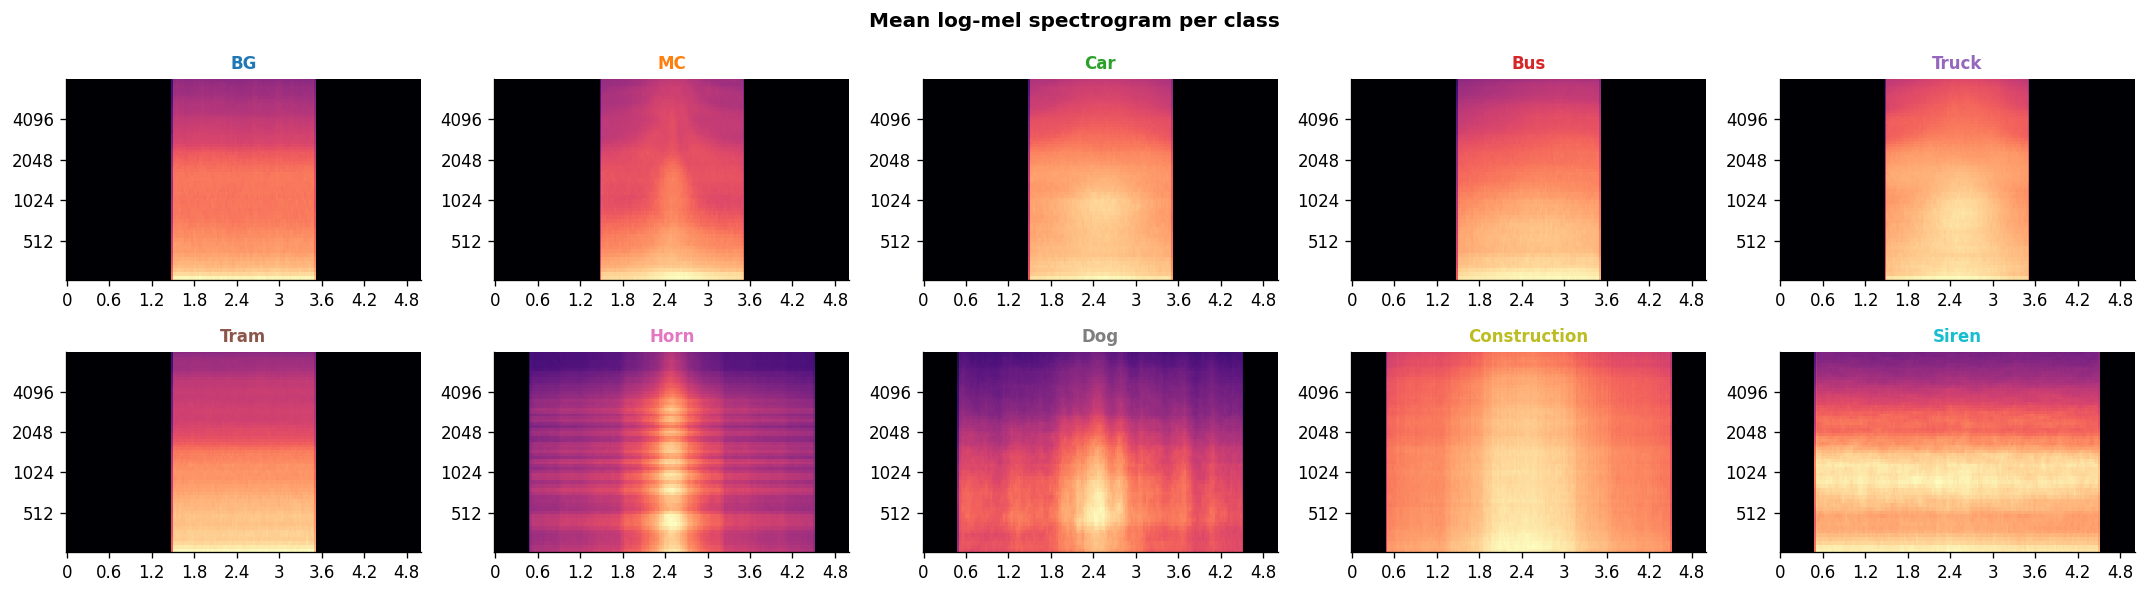

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(18, 5))
fig.suptitle('Mean log-mel spectrogram per class', fontweight='bold')
axes = axes.flatten()

for i, cls in enumerate(CLASSES):
    subset = feat_manifest[feat_manifest['label'] == cls]
    # Load up to 100 spectrograms and average
    sample_rows = subset.sample(min(100, len(subset)), random_state=42)
    specs  = np.stack([np.load(r['logmel_path']) for _, r in sample_rows.iterrows()])
    mean_s = specs.mean(axis=0)

    librosa.display.specshow(mean_s, sr=SR, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel',
                             fmin=FMIN, fmax=FMAX,
                             ax=axes[i], cmap='magma')
    axes[i].set_title(cls, fontweight='bold', fontsize=10,
                      color=plt.cm.tab10.colors[CLASS2IDX[cls]])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig('03_mean_spectrograms.png', bbox_inches='tight')
plt.show()

---
## 6. Disk usage


In [13]:
import os

def folder_size_mb(path: Path) -> float:
    return sum(f.stat().st_size for f in path.rglob('*') if f.is_file()) / 1e6

logmel_mb = folder_size_mb(FEAT_DIR / 'logmel')
pcen_mb   = folder_size_mb(FEAT_DIR / 'pcen')
wav_mb    = folder_size_mb(SEG_DIR)

# Single array size reference
bytes_per_array = N_MELS * T_FRAMES * 4   # float32 = 4 bytes

print("=" * 45)
print("DISK USAGE")
print("=" * 45)
print(f"  WAV segments  : {wav_mb:>8.1f} MB")
print(f"  Log-mel feats : {logmel_mb:>8.1f} MB")
print(f"  PCEN feats    : {pcen_mb:>8.1f} MB")
print(f"  Total         : {wav_mb+logmel_mb+pcen_mb:>8.1f} MB")
print(f"\n  Per spectrogram: {bytes_per_array/1024:.1f} KB  "
      f"({N_MELS}×{T_FRAMES} float32)")

DISK USAGE
  WAV segments  :   1791.9 MB
  Log-mel feats :    450.3 MB
  PCEN feats    :    450.3 MB
  Total         :   2692.6 MB

  Per spectrogram: 54.0 KB  (64×216 float32)


---
## 7. Summary


In [14]:
print("=" * 55)
print("FEATURE EXTRACTION SUMMARY")
print("=" * 55)
print(f"  n_fft       : {N_FFT}")
print(f"  hop_length  : {HOP_LENGTH}")
print(f"  n_mels      : {N_MELS}")
print(f"  fmin / fmax : {FMIN} / {FMAX} Hz")
print(f"  Output shape: ({N_MELS}, {T_FRAMES})  [mels × time]")
print(f"  Features    : log-mel (dB) + PCEN")
print(f"  Total files : {len(feat_manifest)} × 2 = {len(feat_manifest)*2} .npy files")
print(f"  Manifest    : {feat_manifest_path}")
print()


FEATURE EXTRACTION SUMMARY
  n_fft       : 1024
  hop_length  : 512
  n_mels      : 64
  fmin / fmax : 50 / 8000 Hz
  Output shape: (64, 216)  [mels × time]
  Features    : log-mel (dB) + PCEN
  Total files : 8125 × 2 = 16250 .npy files
  Manifest    : data\features_manifest.csv



Time of execution of the file :

In [15]:
# ─── Total notebook runtime ──────────────────────────────────
_elapsed = _time.perf_counter() - _NOTEBOOK_START
_h, _rem = divmod(int(_elapsed), 3600)
_m, _s   = divmod(_rem, 60)

print("=" * 60)
print("TOTAL NOTEBOOK RUNTIME")
print("=" * 60)
if _h:
    print(f"  {_h}h {_m:02d}min {_s:02d}s  ({_elapsed:.1f}s total)")
elif _m:
    print(f"  {_m}min {_s:02d}s  ({_elapsed:.1f}s total)")
else:
    print(f"  {_s}s  ({_elapsed:.2f}s total)")
print("=" * 60)

TOTAL NOTEBOOK RUNTIME
  6min 58s  (418.8s total)
